# Data Visualization with Matplotlib

## Setup Notebook and Kernel

The file is placed in the folder `day_73/` and the kernel used is the uv .venv inside the root folder `100-DAYS-OF-PYTHON/`
<div style="background:rgba(220,220,220,0.3); border-left:4px solid DodgerBlue; padding:10px; width:800px; border-radius:6px;">
<strong style="color:DodgerBlue; display:inline-flex; align-items:center; gap:8px;"><span style="display:inline-flex; align-items:center; justify-content:center; width:20px; height:20px; border-radius:50%; background:DodgerBlue; color:white; font-size:13px; font-weight:700; font-family:Arial, sans-serif; line-height:1;">i</span> Note</strong>
<p style="margin-bottom:5px;">
The choice to go with a local kernel is because Google Colab forces steps to work from its platform.<br>  
Pandas works mainly with CPU so for now no need to use GPUs and the code can be committed.
</p>
</div>

### Get the Data

Either use the provided .csv file or (optionally) get fresh (the freshest?) data from running an SQL query on StackExchange:

Follow this link to run the query from [StackExchange](https://data.stackexchange.com/stackoverflow/query/675441/popular-programming-languages-per-over-time-eversql-com) to get your own .csv file

```sql
select dateadd(month, datediff(month, 0, q.CreationDate), 0) m, TagName, count(*)
from PostTags pt
join Posts q on q.Id=pt.PostId
join Tags t on t.Id=pt.TagId
where TagName in ('java','c','c++','python','c#','javascript','assembly','php','perl','ruby','visual basic','swift','r','object-c','scratch','go','swift','delphi')
and q.CreationDate < dateadd(month, datediff(month, 0, getdate()), 0)
group by dateadd(month, datediff(month, 0, q.CreationDate), 0), TagName
order by dateadd(month, datediff(month, 0, q.CreationDate), 0)
```

### Import Pandas

In [212]:
import sys, pandas as pd
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
print(sys.version)
print(pd.__version__)

3.13.11 (main, Dec  5 2025, 16:06:33) [Clang 17.0.0 (clang-1700.4.4.1)]
3.0.1


### Import Data from CSV and Analyse

In [213]:
df = pd.read_csv("QueryResults.csv", names=['DATE', 'TAG', 'POSTS'], header=0)

Read the first rows

In [214]:
df.head()

,DATE,TAG,POSTS
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,8
2,2008-08-01 00:00:00,c,82
3,2008-08-01 00:00:00,c#,503
4,2008-08-01 00:00:00,c++,164


Read the last rows

In [215]:
df.tail()

,DATE,TAG,POSTS
2924,2026-02-01 00:00:00,php,37
2925,2026-02-01 00:00:00,python,279
2926,2026-02-01 00:00:00,r,79
2927,2026-02-01 00:00:00,ruby,5
2928,2026-02-01 00:00:00,swift,69


Show the shape of the DataFrame

In [216]:
df.shape

(2929, 3)

List of columns

In [217]:
df.columns

Index(['DATE', 'TAG', 'POSTS'], dtype='str')

Missing values from columns

In [218]:
df.isna()

,DATE,TAG,POSTS
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
2924,False,False,False
2925,False,False,False
2926,False,False,False
2927,False,False,False


In [219]:
df.isna().any() #any column that has at leas one missing value

DATE     False
TAG      False
POSTS    False
dtype: bool

In [220]:
df.isna().any(axis=1) #any row that has at leas one missing value

0       False
1       False
2       False
3       False
4       False
        ...  
2924    False
2925    False
2926    False
2927    False
2928    False
Length: 2929, dtype: bool

In [221]:
mask = df.isna().any(axis=1) #any row that has at leas one missing value, this is a 1D boolean mask aligned with index
df[mask] # use the mask to identify rows with at least one column with empty cells

,DATE,TAG,POSTS


In [222]:
df.count()

DATE     2929
TAG      2929
POSTS    2929
dtype: int64

## Challenges

### Number of posts per language

In [223]:
posts_per_language = df.groupby('TAG')['POSTS'].sum().sort_values(ascending=False) # return a Series, sorted
top_language = posts_per_language.index[0]
top_value = posts_per_language.iloc[0]

print(posts_per_language)
print(top_language, top_value)

TAG
javascript    2524473
python        2206951
java          1916381
c#            1622854
php           1463291
c++            814563
r              510566
c              408141
swift          336188
ruby           229227
go              74466
perl            68308
delphi          52553
assembly        45155
Name: POSTS, dtype: int64
javascript 2524473


In [224]:
display(Markdown(f'### The most discussed language is **{top_language}** with **{top_value:,}** posts.'))

### The most discussed language is **javascript** with **2,524,473** posts.

In [225]:
df.groupby('TAG')[['POSTS']].sum().sort_values(by='POSTS', ascending=False) # return a DataFrame, sorted, becayse there are two square brackets [['POSTS']]

,POSTS
TAG,
javascript,2524473
python,2206951
java,1916381
c#,1622854
php,1463291
c++,814563
r,510566
c,408141
swift,336188


### Month of posts per language

In [226]:
valid_rows = df['POSTS'] > 0 # create a series where there is at least 1 post
filtered_df = df[valid_rows] # use the series as a mask

months_per_language = filtered_df.groupby('TAG')['DATE'].count().sort_values(ascending=False) #group by TAG and count the number of months with at least 1 post
top_language = months_per_language.index[0]
top_value = months_per_language.iloc[0]
print(months_per_language)
print(top_language, top_value)

TAG
c#            212
assembly      211
c             211
c++           211
delphi        211
java          211
javascript    211
perl          211
php           211
python        211
ruby          211
r             209
swift         202
go            196
Name: DATE, dtype: int64
c# 212


In [227]:
display(Markdown(f'### The most discussed language is **{top_language}** with **{top_value:,}** months.'))

### The most discussed language is **c#** with **212** months.

## Data Cleaning

### Analyse the 'Date' column

In [228]:
df['DATE'][0]

'2008-07-01 00:00:00'

In [229]:
df.DATE[0] # Only for columns names without spaces

'2008-07-01 00:00:00'

In [230]:
type(df['DATE'][0])
print(pd.to_datetime(df['DATE'][0]))
type(pd.to_datetime(df['DATE'][0]))

2008-07-01 00:00:00


pandas.Timestamp

### Convert DATE column to datetime

In [231]:
df['DATE'] = pd.to_datetime(df['DATE'])
df.head()

,DATE,TAG,POSTS
0,2008-07-01,c#,3
1,2008-08-01,assembly,8
2,2008-08-01,c,82
3,2008-08-01,c#,503
4,2008-08-01,c++,164


## Pivot table

### Create a table where DATE are the rows, TAG are the columns and POSTS are the sum

In [232]:
reshaped_df = df.pivot(index='DATE', columns='TAG', values='POSTS')
print(reshaped_df)

TAG         assembly      c      c#    c++  delphi    go    java  javascript  \
DATE                                                                           
2008-07-01       NaN    NaN     3.0    NaN     NaN   NaN     NaN         NaN   
2008-08-01       8.0   82.0   503.0  164.0    13.0   NaN   220.0       160.0   
2008-09-01      28.0  320.0  1637.0  749.0   104.0   NaN  1121.0       629.0   
2008-10-01      16.0  302.0  1982.0  804.0   112.0   NaN  1142.0       720.0   
2008-11-01      16.0  257.0  1728.0  733.0   139.0   NaN   951.0       581.0   
...              ...    ...     ...    ...     ...   ...     ...         ...   
2025-10-01      41.0  118.0   284.0  230.0    22.0  32.0   260.0       260.0   
2025-11-01      17.0  101.0   248.0  208.0    14.0  28.0   241.0       214.0   
2025-12-01      19.0   67.0   192.0  150.0    16.0  20.0   187.0       150.0   
2026-01-01      19.0   82.0   155.0  145.0    19.0  25.0   157.0       164.0   
2026-02-01      11.0   57.0   142.0  128

<div style="background:rgba(220,220,220,0.3); border-left:4px solid LimeGreen; padding:10px; width:800px; border-radius:6px;">
<strong style="color:LimeGreen; display:inline-flex; align-items:center; gap:8px;"><span style="display:inline-flex; align-items:center; justify-content:center; width:20px; height:20px; border-radius:50%; background:LimeGreen; color:white; font-size:19px; font-weight:700; font-family:Arial, sans-serif; line-height:1;">+</span> Tips</strong>
<p style="margin-bottom:5px;">
NaN here are there because it means there is <strong>no combination</strong> with the given pivot table. 
Differently than the NaN where the values is not present
</p>
</div>

In [233]:
reshaped_df.shape

(212, 14)

In [234]:
reshaped_df.columns

Index(['assembly', 'c', 'c#', 'c++', 'delphi', 'go', 'java', 'javascript',
       'perl', 'php', 'python', 'r', 'ruby', 'swift'],
      dtype='str', name='TAG')

In [235]:
reshaped_df.count()

TAG
assembly      211
c             211
c#            212
c++           211
delphi        211
go            196
java          211
javascript    211
perl          211
php           211
python        211
r             209
ruby          211
swift         202
dtype: int64

### Fill NaN with 0 number

In [239]:
reshaped_df.fillna(0, inplace=True)

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2008-08-01,8.0,82.0,503.0,164.0,13.0,0.0,220.0,160.0,28.0,157.0,119.0,0.0,68.0,0.0
2008-09-01,28.0,320.0,1637.0,749.0,104.0,0.0,1121.0,629.0,128.0,471.0,533.0,6.0,285.0,0.0
2008-10-01,16.0,302.0,1982.0,804.0,112.0,0.0,1142.0,720.0,128.0,603.0,504.0,0.0,245.0,0.0
2008-11-01,16.0,257.0,1728.0,733.0,139.0,0.0,951.0,581.0,97.0,497.0,446.0,1.0,154.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,41.0,118.0,284.0,230.0,22.0,32.0,260.0,260.0,7.0,92.0,637.0,180.0,10.0,128.0
2025-11-01,17.0,101.0,248.0,208.0,14.0,28.0,241.0,214.0,2.0,78.0,522.0,128.0,9.0,103.0
2025-12-01,19.0,67.0,192.0,150.0,16.0,20.0,187.0,150.0,6.0,53.0,409.0,98.0,6.0,88.0


Check if any value NaN is left

In [237]:
reshaped_df.isna().values.any()

np.False_

## Data Visualisation

### Number of posts comparison between 3 languages

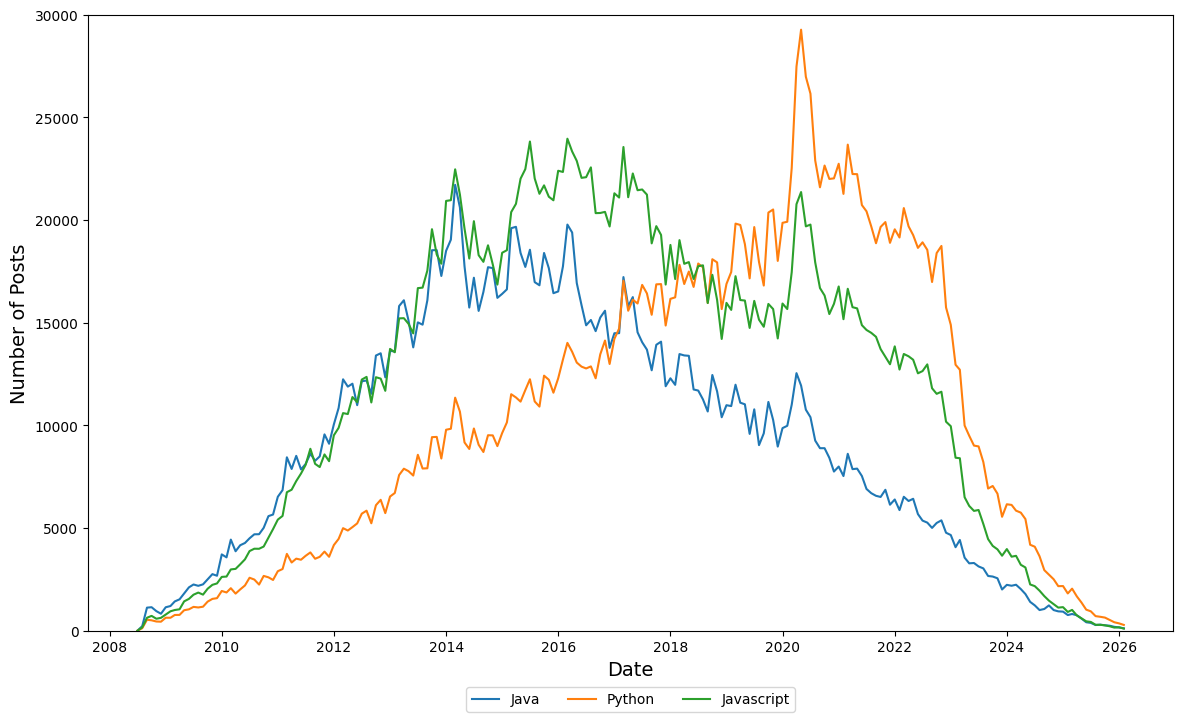

In [288]:
languages = ['java', 'python', 'javascript']
plt.figure(figsize=(14,8))
plt.xticks(fontsize=10)
plt.xlabel('Date', fontsize=14)
plt.yticks(fontsize=10)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 30000)

for lang in languages:
    plt.plot(reshaped_df.index, reshaped_df[lang], label=lang.capitalize())

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3)

### Number of posts comparison between all languages

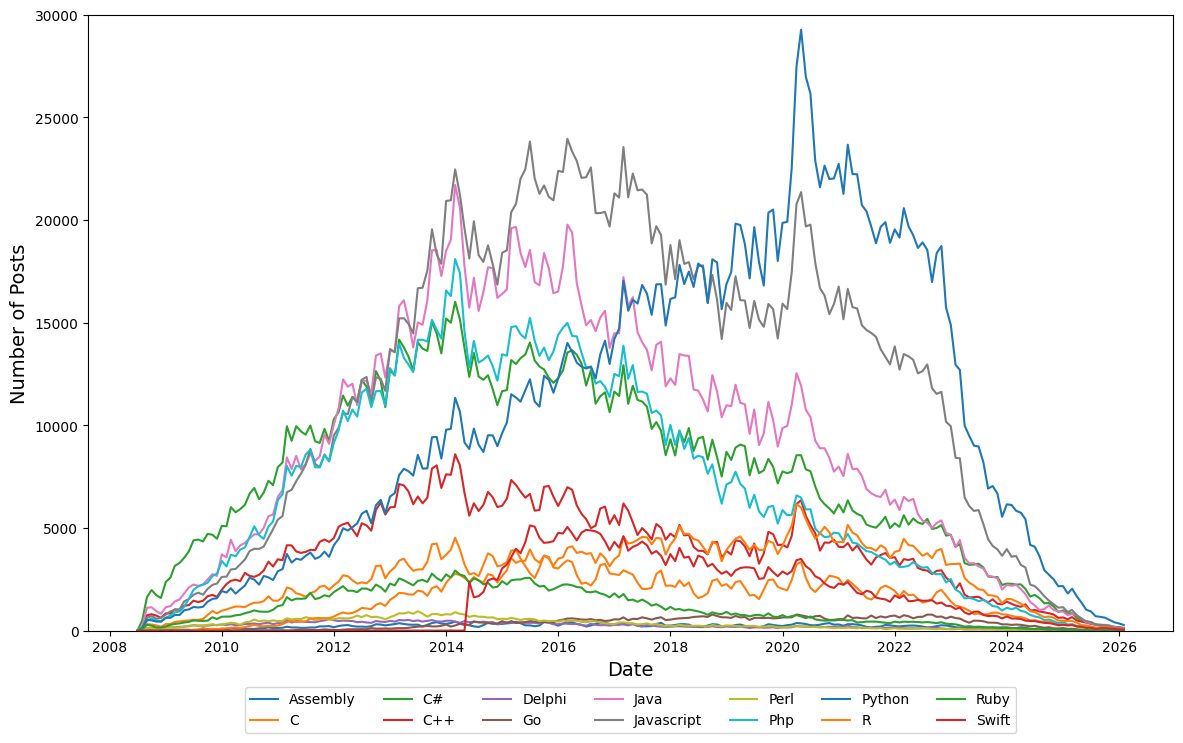

In [308]:
languages = reshaped_df.columns
plt.figure(figsize=(14,8))
plt.xticks(fontsize=10)
plt.xlabel('Date', fontsize=14)
plt.yticks(fontsize=10)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 30000)

for lang in languages:
    plt.plot(reshaped_df.index, reshaped_df[lang], label=lang.capitalize())

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=7)

### Relative Popularity comparison between three languages

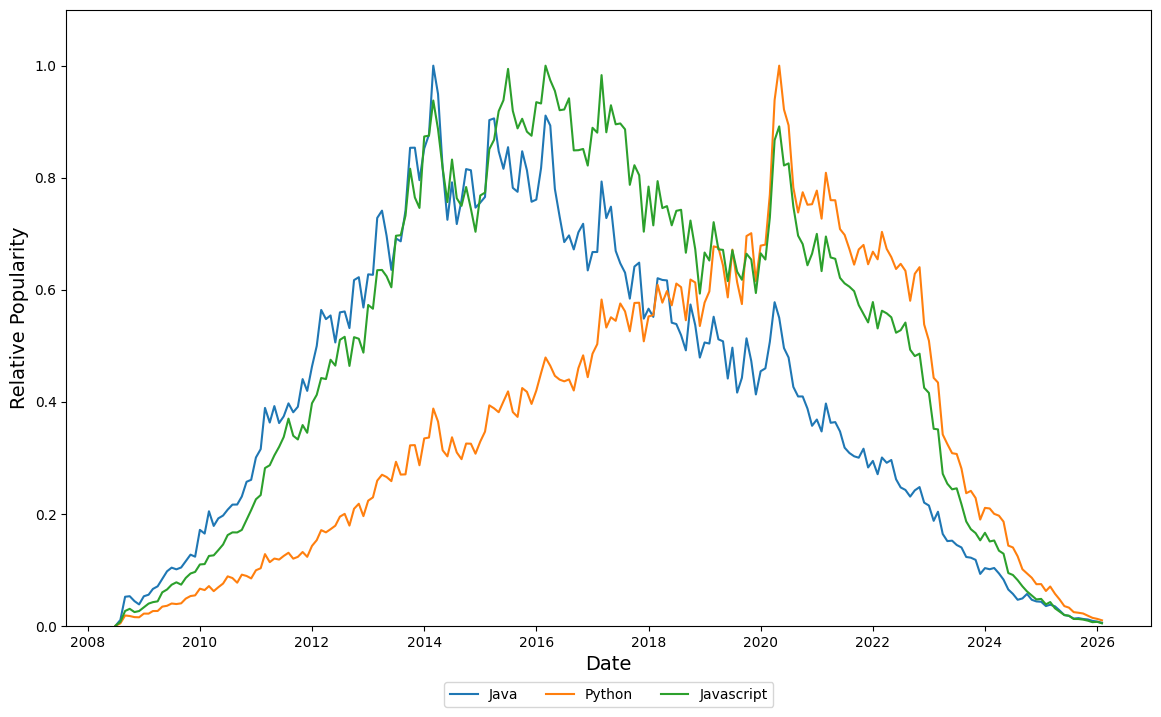

In [295]:
languages = ['java', 'python', 'javascript']
normalized = reshaped_df / reshaped_df.max()
plt.figure(figsize=(14,8))
plt.xticks(fontsize=10)
plt.xlabel('Date', fontsize=14)
plt.yticks(fontsize=10)
plt.ylabel('Relative Popularity', fontsize=14)
plt.ylim(0, 1.1)

for lang in languages:
    plt.plot(normalized.index, normalized[lang], label=lang.capitalize())

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3)

### Platform decline in aggregate posts numbers

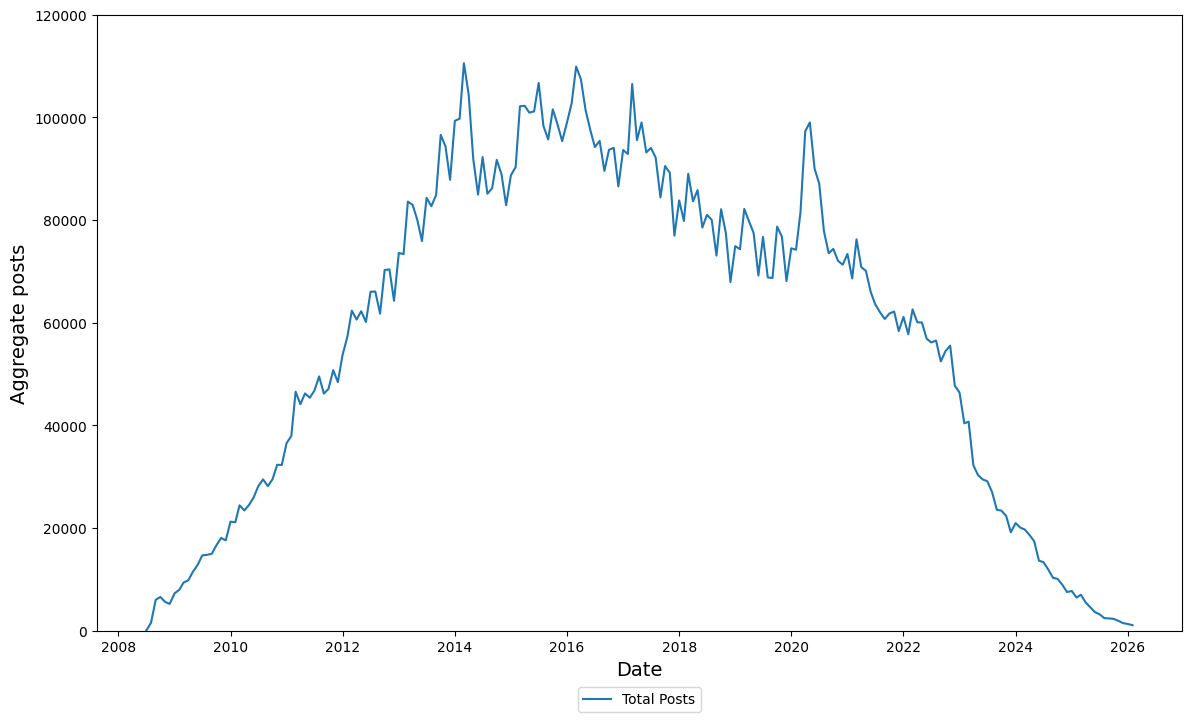

In [313]:
total_posts = reshaped_df.sum(axis=1)

plt.figure(figsize=(14,8))
plt.xticks(fontsize=10)
plt.xlabel('Date', fontsize=14)
plt.yticks(fontsize=10)
plt.ylabel('Aggregate posts', fontsize=14)
plt.ylim(0, 120000)
plt.plot(total_posts.index, total_posts, label='Total Posts')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=1)

### Rolling values to smooth TimeSeries

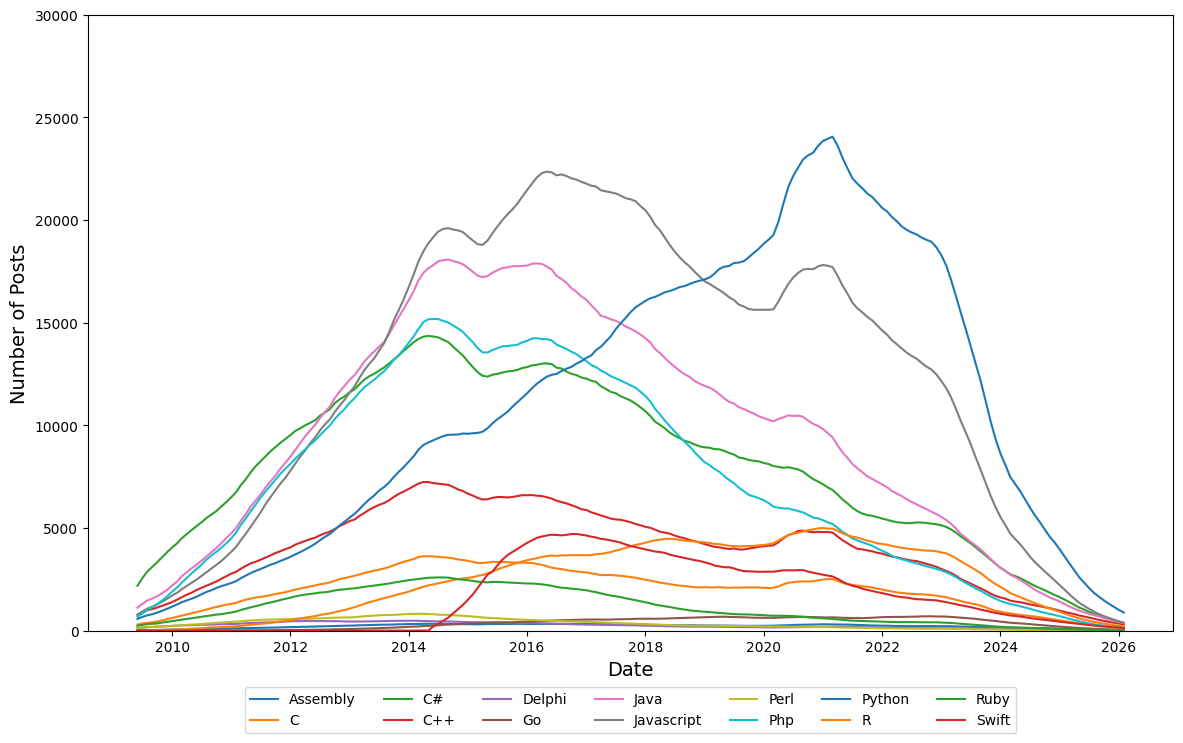

In [317]:
roll_df = reshaped_df.rolling(window=12).mean()
languages = roll_df.columns
plt.figure(figsize=(14,8))
plt.xticks(fontsize=10)
plt.xlabel('Date', fontsize=14)
plt.yticks(fontsize=10)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 30000)

for lang in languages:
    plt.plot(roll_df.index, roll_df[lang], label=lang.capitalize())

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=7)